<a href="https://colab.research.google.com/github/Dhruti-Avadhani2004/Artificial-Intelligence-for-Cybersecurity/blob/main/Tools%20of%20the%20Trade/AIML_in_Cybersecurity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Types of Machine Learning
## Supervised Learning
Training is conducted using an input dataset, where the type of output that we need to obtain is already known.
E.g., A spam filter classifier is trained by submitting a dataset of emails previously classified as spam or ham.

This algorithm will learn to classify new emails it will receive in the future based on the aforementioned dataset.

## Unsupervised Learning
The algorithms try to classify the data independently, without the aid of the classification already provided by an analyst.
**In the security context, the unsupervised learning algorithm is important for identifying *new* forms of malware, frauds and email phishing.**

## Reinforcement Learning
Here, a different strategy of trial and error is followed. It draws information from the feedback obtained during learning and aim for maximizing the reward that is finally obtained based on the number of correct decisions the algorithm has selected.

# Supervised Learning Example - Linear Regression

*   Using scikit-learn, LinearRegression class (included in the linear_model package of sci-kit learn)
*   Trained on the dataset by invoking rand() from numpy
*   Training of the model is carried out by fit() method on object of LinearRegression class
*   We shall try to predict data that is not included in the training dataset by the predict() method
*   Printing the values on the screen using scatter() and plot() from matplotlib library.







It is a 4 step process

```
# This is formatted as code
1. GET DATA       → real dataset or generate synthetic data
2. SHAPE DATA     → reshape X to 2D with [:, np.newaxis]
3. FIT MODEL      → create model, call .fit(X, y)
4. VISUALIZE      → scatter real data, plot predicted line
```



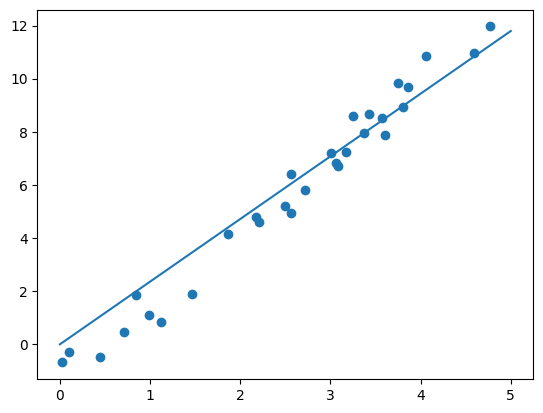

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression

pool = np.random.RandomState(10)
x = 5 * pool.rand(30) # range between 0 and 5 for 30 random values
y = 3 * x - 2 + pool.randn(30) # just adding some noise to make the data seem realistic
# y = mx + c
# m = 3; c = -2

lreg = LinearRegression(fit_intercept=False)

X = x[:, np.newaxis] # changes the 1D data to 2D data as sklearn always needs X as 2D
# y is always in 1D and hence we dont give it a new axis
lreg.fit(X, y) # model training - supervised with X as 2D input data and y as a corresponding output value
lspace = np.linspace(0,5) # creates a linear space with 50 evenly spaced points so the regression line looks smooth
Xreg = lspace[:, np.newaxis] # Create the 2D testing input data
yreg = lreg.predict(Xreg) # predict yreg values using the lreg model using input data Xreg


plt.scatter(x,y) # plot noisy data
plt.plot(Xreg, yreg) # plot smooth regression line

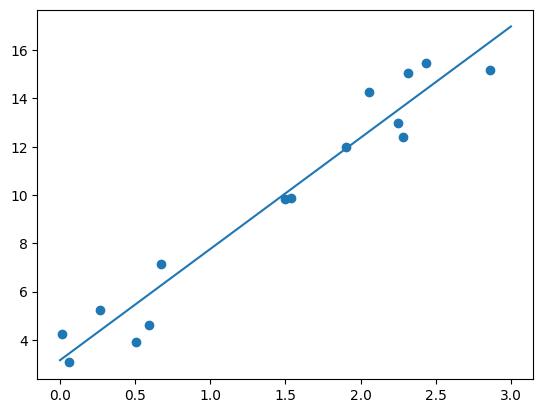

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

#DATA
data = np.random.RandomState(10)
x = 3 * data.rand(15)
y = 5 * x + 2 + data.randn(15)
# y = mx + c

#SHAPE
X = x[:, np.newaxis]

#FIT
lreg = LinearRegression(fit_intercept=True) # better with intercept as true, that way the model learns the +2 intercept and it doesnt get pulled toward 0
lreg.fit(X,y)

#VISUALIZE
lspace = np.linspace(0,3)
Xreg = lspace[:, np.newaxis]
yreg = lreg.predict(Xreg)

plt.scatter(x,y)
plt.plot(Xreg, yreg)

# Un-supervised Learning Example

*   The training data is loaded from a file in .csv format
*   stored in a DataFrame object of the pandas Python library
*   The reduction of dimensionality prevents the disadvantages connected to the
phenomenon of the curse of dimensionality, improves the computational
efficiency, and simplifies the visualization of the data
*   The technique we will use for dimensionality reduction is known
as principal component analysis (PCA), and is available in the scikit-learn
library.








In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
data_df = pd.read_csv("/content/clustering.csv")
data_df.describe()
X_data = data_df.drop('class_1', axis = 1)
y_data = data_df['class_1']


In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components = 2)
pca.fit(X_data)
X_2D = pca.transform(X_data)
data_df['PCA1'] = X_2D[:, 0]
data_df['PCA2'] = X_2D[:, 1]

In [ ]:
from sklearn.mixture import GaussianMixture

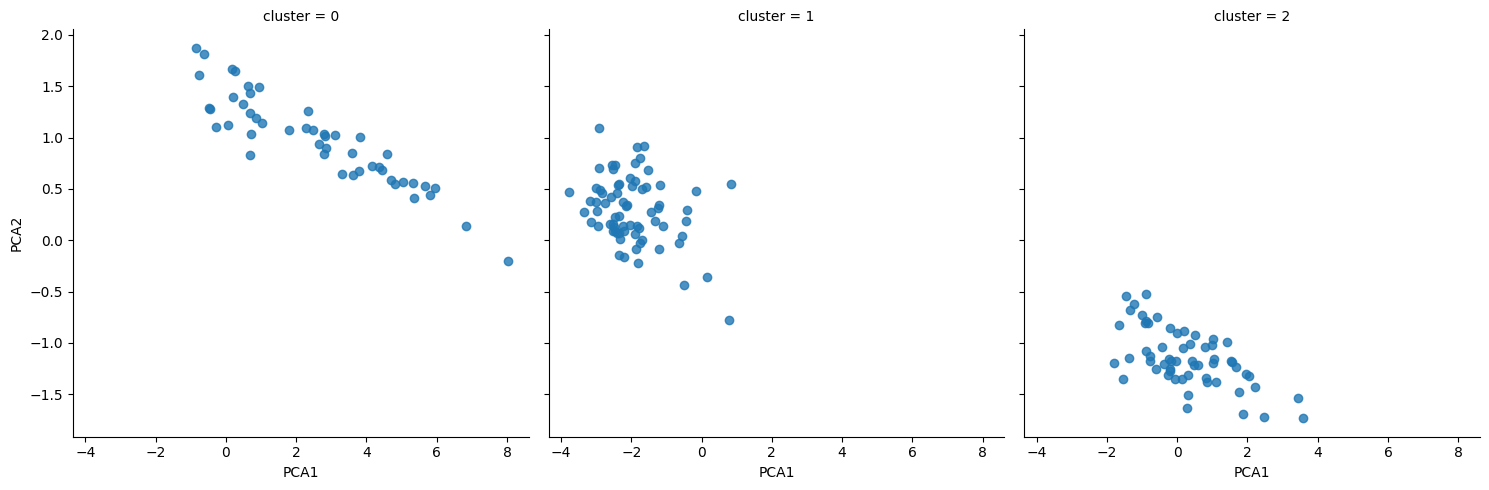

In [ ]:
gm = GaussianMixture(n_components=3, covariance_type='full')
gm.fit(X_data)
y_gm = gm.predict(X_data)
data_df['cluster'] = y_gm
sns.lmplot(x="PCA1", y="PCA2", data=data_df, col='cluster', fit_reg=False)